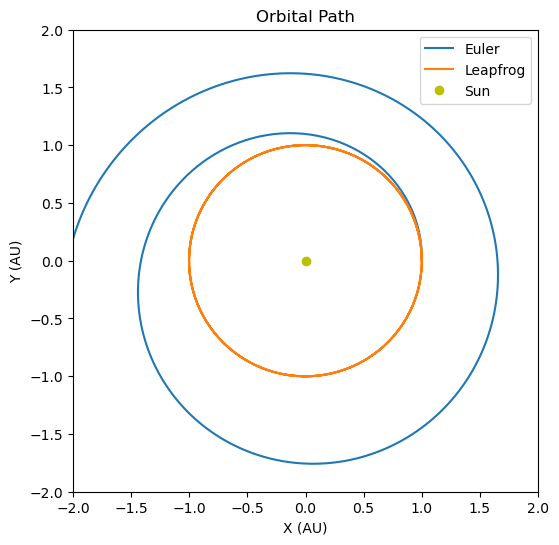

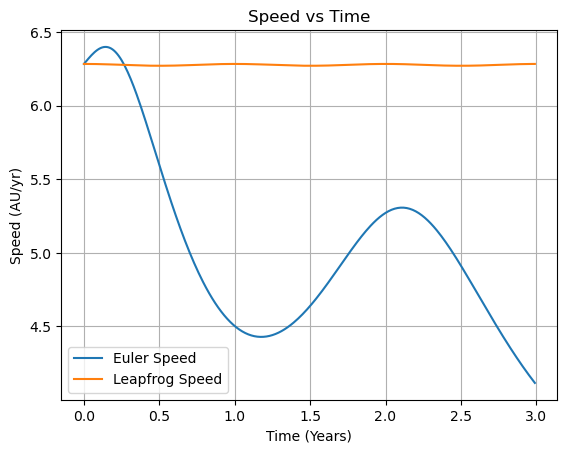

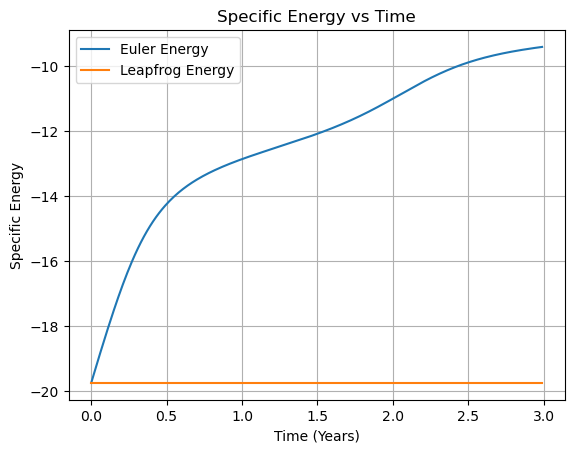

In [13]:
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Basic Setup & Constants
# ---------------------------------------------------------
G = 4 * (math.pi ** 2)  # Gravity constant
M = 1.0                 # Mass of Sun
current_time = 0.0
dt = 0.01
t_max = 3.0
steps = round(t_max/dt)             # 3 years / 0.01 dt = 300 steps

# Starting variables for Euler (x, y, vx, vy)
ex, ey = 1.0, 0.0
evx, evy = 0.0, 2 * math.pi

# Starting variables for Leapfrog (x, y, vx, vy)
lx, ly = 1.0, 0.0
lvx, lvy = 0.0, 2 * math.pi

# Empty lists to save our data for plotting later
e_path_x, e_path_y, e_speed, e_energy = [], [], [], []
l_path_x, l_path_y, l_speed, l_energy = [], [], [], []
time_list = []

# ---------------------------------------------------------
# 2. The Core Physics Loop
# ---------------------------------------------------------
for _ in range(steps):

    time_list.append(current_time)
    
    # --- EULER METHOD ---
    # 1. Find distance from sun (r) using Pythagorean theorem
    er = math.sqrt(ex**2 + ey**2)
    
    # 2. Calculate acceleration in x and y directions
    eax = -(G * M / er**3) * ex
    eay = -(G * M / er**3) * ey
    
    # 3. Save current stats before they change
    e_path_x.append(ex)
    e_path_y.append(ey)
    e_speed.append(math.sqrt(evx**2 + evy**2))
    e_energy.append(0.5 * (evx**2 + evy**2) - (G * M / er))
    
    # 4. Update position, then velocity
    ex = ex + evx * dt
    ey = ey + evy * dt
    evx = evx + eax * dt
    evy = evy + eay * dt

    
    # --- LEAPFROG METHOD ---
    lr = math.sqrt(lx**2 + ly**2)
    lax = -(G * M / lr**3) * lx
    lay = -(G * M / lr**3) * ly
    
    # Save current stats
    l_path_x.append(lx)
    l_path_y.append(ly)
    l_speed.append(math.sqrt(lvx**2 + lvy**2))
    l_energy.append(0.5 * (lvx**2 + lvy**2) - (G * M / lr))
    
    # 1. KICK: Update velocity by half a time step
    lvx_half = lvx + lax * (dt / 2.0)
    lvy_half = lvy + lay * (dt / 2.0)
    
    # 2. DRIFT: Update position by a full time step using half-velocity
    lx = lx + lvx_half * dt
    ly = ly + lvy_half * dt
    
    # 3. KICK: Update velocity by the remaining half step using NEW position
    lr_new = math.sqrt(lx**2 + ly**2)
    lax_new = -(G * M / lr_new**3) * lx
    lay_new = -(G * M / lr_new**3) * ly
    
    lvx = lvx_half + lax_new * (dt / 2.0)
    lvy = lvy_half + lay_new * (dt / 2.0)

    current_time += dt

# ---------------------------------------------------------
# 3. Simple Plots
# ---------------------------------------------------------
# Plot 1: The Trajectory
plt.figure(1, figsize=(6, 6))
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.plot(e_path_x, e_path_y, label="Euler")
plt.plot(l_path_x, l_path_y, label="Leapfrog")
plt.plot(0, 0, 'yo', label="Sun") # 'yo' makes a yellow dot
plt.title("Orbital Path")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()

# Plot 2: Speed over time
plt.figure(2)
plt.plot(time_list, e_speed, label="Euler Speed")
plt.plot(time_list, l_speed, label="Leapfrog Speed")
plt.title("Speed vs Time")
plt.xlabel("Time (Years)")
plt.ylabel("Speed (AU/yr)")
plt.grid(True)
plt.legend()

# Plot 3: Energy over time
plt.figure(3)
plt.plot(time_list, e_energy, label="Euler Energy")
plt.plot(time_list, l_energy, label="Leapfrog Energy")
plt.title("Specific Energy vs Time")
plt.xlabel("Time (Years)")
plt.ylabel("Specific Energy")
plt.grid(True)
plt.legend()

plt.show()

Rendering movie... this might take a minute.
Movie saved as basic_orbit_movie.mp4!


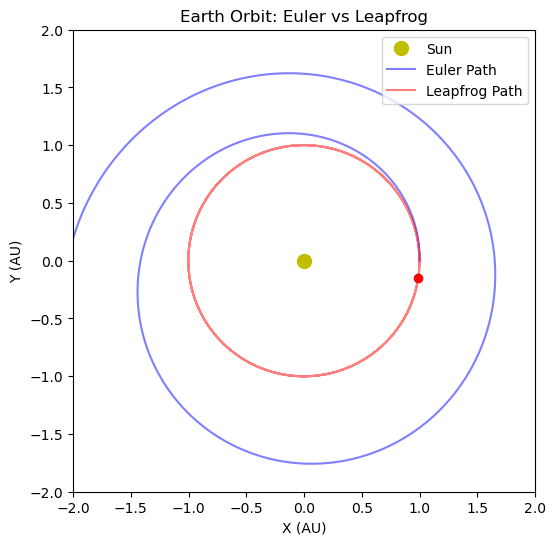

In [11]:
import matplotlib.animation as animation

# ---------------------------------------------------------
# 4. Generate the Movie File
# ---------------------------------------------------------
# Create a new figure for the movie
fig_movie, ax_movie = plt.subplots(figsize=(6, 6))
ax_movie.set_xlim(-2, 2)
ax_movie.set_ylim(-2, 2)
ax_movie.set_aspect('equal') # Ensures the circular orbit doesn't look stretched
ax_movie.set_xlabel('X (AU)')
ax_movie.set_ylabel('Y (AU)')
ax_movie.set_title("Earth Orbit: Euler vs Leapfrog")

# Draw the Sun
ax_movie.plot(0, 0, 'yo', markersize=10, label="Sun")

# Setup empty lines for the trails and dots for the planets
euler_trail, = ax_movie.plot([], [], 'b-', alpha=0.5, label="Euler Path")
euler_planet, = ax_movie.plot([], [], 'bo')

leap_trail, = ax_movie.plot([], [], 'r-', alpha=0.5, label="Leapfrog Path")
leap_planet, = ax_movie.plot([], [], 'ro')

ax_movie.legend(loc='upper right')

# This function tells the computer what to draw on each frame
def draw_frame(i):
    # Draw the trail up to the current step 'i'
    euler_trail.set_data(e_path_x[:i], e_path_y[:i])
    # Draw the planet at exactly step 'i' (matplotlib needs it in a list [])
    euler_planet.set_data([e_path_x[i]], [e_path_y[i]]) 
    
    leap_trail.set_data(l_path_x[:i], l_path_y[:i])
    leap_planet.set_data([l_path_x[i]], [l_path_y[i]])
    
    return euler_trail, euler_planet, leap_trail, leap_planet

print("Rendering movie... this might take a minute.")

# Create the animation. 
# frames=range(0, steps, 2) means we skip 2 steps per frame so it doesn't take forever to render
ani = animation.FuncAnimation(fig_movie, draw_frame, frames=range(0, steps, 2), interval=20, blit=True)

# Save as an mp4 using FFmpeg
writer = animation.FFMpegWriter(fps=30)
ani.save('orbit_movie.mp4', writer=writer)

print("Movie saved as basic_orbit_movie.mp4!")

For a perfectly circular orbit, the true speed is a constant $2\pi\text{ AU/yr}$. The leapfrog speed is almost constant while the Euler speed decreases with oscillation, Leapfrog energy is almost constant (conserved energy) while Euler energy is showing positive secular drift. Euler orbits are inherently unstable for central-force problems because the error vector always points outward, causing the orbit to spiral. Leapfrog is symplectic; it perfectly conserves a "shadow Hamiltonian" that is very close to the true energy, resulting in stable, closed orbits.